# BIM 430 - Derin Öğrenme Projesi
## Model 2: LSTM (Literatür Mimarisi - Sıfırdan Eğitim)

**Veri Seti:** IMDB Film Yorumları (Model 1 ile AYNI)

**Mimari:** Embedding → LSTM → Dense → Dropout → Sigmoid

**Önemli Notlar:**
- Bu mimari literatürdeki klasik RNN tabanlı metin sınıflandırma yaklaşımından gelmektedir (Hochreiter & Schmidhuber, 1997).
- Model **sıfırdan eğitilmektedir**, pretrained ağırlık kullanılmamıştır.
- Transfer learning YOK, fine-tuning YOK.
- Veri pipeline'ı ve hiperparametreler Model 1 ile birebir aynıdır (adil karşılaştırma için).

## 1. Kütüphaneler ve Ayarlar

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import random
import os
import json

# Tekrarlanabilirlik için seed sabitleme (Model 1 ile AYNI!)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# GPU kontrolü
print("TensorFlow versiyonu:", tf.__version__)
print("GPU kullanılabilir:", tf.config.list_physical_devices('GPU'))

TensorFlow versiyonu: 2.19.0
GPU kullanılabilir: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Google Drive Bağlantısı

Tüm çıktılar `deeplearning/model2/` klasörüne kaydedilecek.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH = '/content/drive/MyDrive/deeplearning/model2'
os.makedirs(SAVE_PATH, exist_ok=True)
print(f"Kayıt klasörü: {SAVE_PATH}")

Mounted at /content/drive
Kayıt klasörü: /content/drive/MyDrive/deeplearning/model2


## 3. Veri Yükleme ve Ön İşleme (Model 1 ile BİREBİR AYNI)

⚠️ Model 1 ile adil karşılaştırma yapabilmek için:
- Aynı VOCAB_SIZE
- Aynı MAX_LEN
- Aynı SEED (veri bölünmesi deterministik)
- Aynı validation split

Bu sabitler değişirse karşılaştırma adil olmaz!

In [3]:
# Hiperparametreler (Model 1 ile AYNI)
VOCAB_SIZE = 10000
MAX_LEN = 250
EMBED_DIM = 128
BATCH_SIZE = 64
EPOCHS = 15

# Veriyi yükle (IMDB - Keras hazır veri seti)
(x_train_full, y_train_full), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print(f"Eğitim örnek sayısı: {len(x_train_full)}")
print(f"Test örnek sayısı: {len(x_test)}")
print(f"Sınıf dağılımı (eğitim): {np.bincount(y_train_full)}")
print(f"Sınıf dağılımı (test): {np.bincount(y_test)}")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Eğitim örnek sayısı: 25000
Test örnek sayısı: 25000
Sınıf dağılımı (eğitim): [12500 12500]
Sınıf dağılımı (test): [12500 12500]


In [4]:
# Padding (Model 1 ile AYNI)
x_train_full = pad_sequences(x_train_full, maxlen=MAX_LEN, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=MAX_LEN, padding='post', truncating='post')

# Validation split (Model 1 ile AYNI - seed sabit olduğu için deterministik)
val_size = 2500
x_val = x_train_full[:val_size]
y_val = y_train_full[:val_size]
x_train = x_train_full[val_size:]
y_train = y_train_full[val_size:]

print(f"Eğitim: {x_train.shape}, Validation: {x_val.shape}, Test: {x_test.shape}")
print(f"Train sınıf dağılımı: {np.bincount(y_train)}")
print(f"Val sınıf dağılımı: {np.bincount(y_val)}")

Eğitim: (22500, 250), Validation: (2500, 250), Test: (25000, 250)
Train sınıf dağılımı: [11282 11218]
Val sınıf dağılımı: [1218 1282]


## 4. Model 2: LSTM Mimarisi

### Mimari Kararları

Bu, literatürde metin sınıflandırma için sıkça kullanılan **klasik LSTM** yaklaşımıdır:

- **Embedding (128 boyut):** Model 1 ile aynı boyut, sıfırdan öğreniliyor
- **LSTM (128 birim):** Metindeki sıralı bağımlılıkları (uzun mesafeli ilişkiler) öğrenir
- **Dropout (0.5):** Overfitting'e karşı
- **Dense (32, ReLU):** Öznitelik sıkıştırma
- **Dropout (0.3):** İkinci katman regularization
- **Sigmoid çıkış:** İkili sınıflandırma

### CNN (Model 1) ile Farkı

| Özellik | Model 1 (TextCNN) | Model 2 (LSTM) |
|---------|-------------------|----------------|
| Yaklaşım | N-gram desenleri | Sıralı işleme |
| Hız | Hızlı (paralel) | Yavaş (sıralı) |
| Konum bilgisi | Yok (pooling ile atılır) | Korunur |
| Uzun bağımlılık | Zayıf | Güçlü ("not good" gibi) |

### Kaynak
Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural computation*, 9(8), 1735-1780.

In [5]:
def build_lstm_model():
    """Literatür LSTM mimarisi - sıfırdan eğitim"""
    inputs = keras.Input(shape=(MAX_LEN,), name='input_tokens')

    # Embedding - sıfırdan eğitilir (pretrained DEĞİL)
    x = layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        input_length=MAX_LEN,
        name='embedding'
    )(inputs)

    # LSTM katmanı - sıralı işleme
    x = layers.LSTM(
        units=128,
        dropout=0.2,          # input dropout
        recurrent_dropout=0.0, # T4'te hızlı çalışması için 0
        name='lstm'
    )(x)

    # Regularization ve dense katmanlar
    x = layers.Dropout(0.5, name='dropout_1')(x)
    x = layers.Dense(32, activation='relu', name='dense_hidden')(x)
    x = layers.Dropout(0.3, name='dropout_2')(x)

    # Çıkış
    outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

    model = keras.Model(inputs, outputs, name='LSTM_Literature')
    return model

model_2 = build_lstm_model()
model_2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Literature"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,415,745 (5.40 MB)

 Trainable params: 1,415,745 (5.40 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Model mimarisini görselleştir
keras.utils.plot_model(
    model_2,
    to_file=f'{SAVE_PATH}/model2_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    dpi=80
)
print(f"Mimari görseli kaydedildi: {SAVE_PATH}/model2_architecture.png")

Mimari görseli kaydedildi: /content/drive/MyDrive/deeplearning/model2/model2_architecture.png


## 5. Model Eğitimi

⏱️ **Dikkat:** LSTM sıralı işlem yaptığı için CNN'den çok daha yavaştır. T4 GPU'da epoch başına yaklaşık 60-90 saniye sürebilir.

In [7]:
# Derleme (Model 1 ile AYNI optimizer ve loss)
model_2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Callback'ler (Model 1 ile AYNI)
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Eğitim
history_2 = model_2.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.5152 - loss: 0.6932 - val_accuracy: 0.5276 - val_loss: 0.6910
Epoch 2/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5322 - loss: 0.6897 - val_accuracy: 0.5264 - val_loss: 0.6859
Epoch 3/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5334 - loss: 0.6857 - val_accuracy: 0.5336 - val_loss: 0.6812
Epoch 4/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5759 - loss: 0.6455 - val_accuracy: 0.5524 - val_loss: 0.6714
Epoch 5/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.6127 - loss: 0.5949 - val_accuracy: 0.5692 - val_loss: 0.6844
Epoch 6/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7081 - loss: 0.5371 - val_accuracy: 0.7648 - val_loss: 0.5460
Epoch 7/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8767 - loss: 0.3202 - val_accuracy: 0.8444 - val_loss: 0.3907
Epoch 8/15
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9221 - loss: 0.2182 - val_acc

## 6. Eğitim Grafikleri (Loss ve Accuracy)

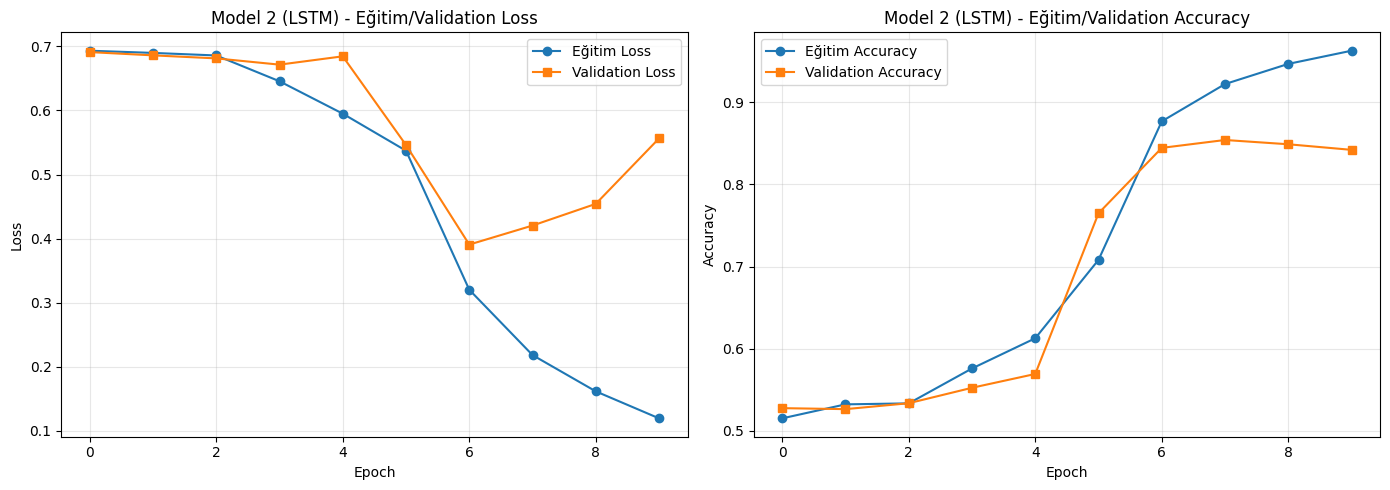

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss grafiği
axes[0].plot(history_2.history['loss'], label='Eğitim Loss', marker='o')
axes[0].plot(history_2.history['val_loss'], label='Validation Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Model 2 (LSTM) - Eğitim/Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(history_2.history['accuracy'], label='Eğitim Accuracy', marker='o')
axes[1].plot(history_2.history['val_accuracy'], label='Validation Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Model 2 (LSTM) - Eğitim/Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_PATH}/model2_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Test Seti Değerlendirme ve Metrikler

In [9]:
# Test seti üzerinde tahmin
y_pred_proba = model_2.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Metrikler
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 50)
print("MODEL 2 - LSTM - Test Sonuçları")
print("=" * 50)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=['Negatif', 'Pozitif']))

391/391 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
MODEL 2 - LSTM - Test Sonuçları
Accuracy : 0.8387
Precision: 0.8186
Recall   : 0.8703
F1-Score : 0.8437

Detaylı Sınıflandırma Raporu:
              precision    recall  f1-score   support

     Negatif       0.86      0.81      0.83     12500
     Pozitif       0.82      0.87      0.84     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



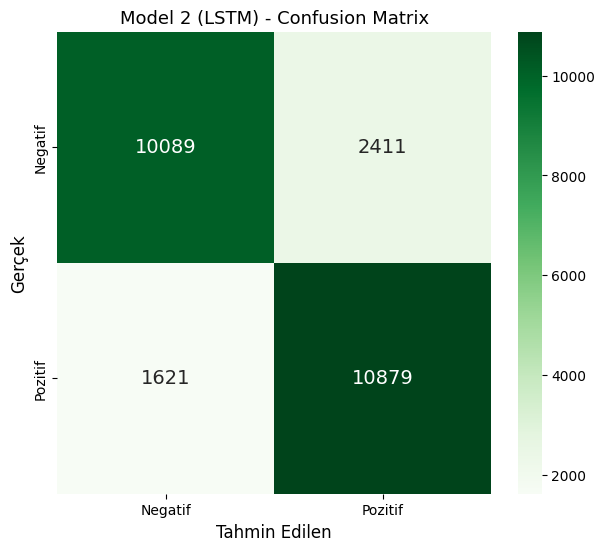

In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negatif', 'Pozitif'],
            yticklabels=['Negatif', 'Pozitif'],
            cbar=True, annot_kws={'size': 14})
plt.xlabel('Tahmin Edilen', fontsize=12)
plt.ylabel('Gerçek', fontsize=12)
plt.title('Model 2 (LSTM) - Confusion Matrix', fontsize=13)
plt.savefig(f'{SAVE_PATH}/model2_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Sonuçları Drive'a Kaydet

In [11]:
# Metrikleri JSON olarak kaydet
results_model_2 = {
    'model_name': 'LSTM (Literature)',
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'confusion_matrix': cm.tolist(),
    'history': {k: [float(v) for v in vals] for k, vals in history_2.history.items()},
    'hyperparameters': {
        'vocab_size': VOCAB_SIZE,
        'max_len': MAX_LEN,
        'embed_dim': EMBED_DIM,
        'lstm_units': 128,
        'batch_size': BATCH_SIZE,
        'optimizer': 'Adam',
        'learning_rate': 1e-3,
        'seed': SEED
    }
}

# JSON
json_path = f'{SAVE_PATH}/results_model_2.json'
with open(json_path, 'w') as f:
    json.dump(results_model_2, f, indent=2)
print(f"✅ JSON kaydedildi: {json_path}")

# Model
model_path = f'{SAVE_PATH}/model_2_lstm.keras'
model_2.save(model_path)
print(f"✅ Model kaydedildi: {model_path}")

# Tüm dosyaları listele
print("\n" + "="*60)
print("MODEL 2 - TÜM DOSYALAR")
print("="*60)
for f in sorted(os.listdir(SAVE_PATH)):
    filepath = f'{SAVE_PATH}/{f}'
    size_kb = os.path.getsize(filepath) / 1024
    print(f"  📄 {f} ({size_kb:.1f} KB)")

✅ JSON kaydedildi: /content/drive/MyDrive/deeplearning/model2/results_model_2.json
✅ Model kaydedildi: /content/drive/MyDrive/deeplearning/model2/model_2_lstm.keras

MODEL 2 - TÜM DOSYALAR
  📄 model2_architecture.png (52.4 KB)
  📄 model2_confusion_matrix.png (26.6 KB)
  📄 model2_lstm.ipynb (30.1 KB)
  📄 model2_training_curves.png (64.7 KB)
  📄 model_2_lstm.keras (16630.0 KB)
  📄 results_model_2.json (1.6 KB)


## 9. README.md Oluştur

In [12]:
readme_content = f"""# Model 2: LSTM (Literatür Mimarisi)

**BIM 430 — Derin Öğrenme Projesi**

---

## 📌 Proje Özeti

Bu klasör, IMDB film yorumları üzerinde duygu analizi yapan projenin **ikinci modelini** içerir. Model literatürde yaygın kullanılan klasik **LSTM** (Long Short-Term Memory) mimarisidir ve sıfırdan eğitilmiştir.

---

## 📊 Veri Seti

Model 1 ile **birebir aynı** veri seti ve ön işleme kullanılmıştır:
- Keras IMDB Dataset
- 22.500 eğitim / 2.500 validation / 25.000 test
- VOCAB_SIZE = 10.000, MAX_LEN = 250
- SEED = 42 (deterministik bölünme)

---

## 🧠 Model Mimarisi

```
Input (250 token)
    ↓
Embedding (10000 → 128 boyut, sıfırdan)
    ↓
LSTM (128 birim, dropout=0.2)
    ↓
Dropout (0.5)
    ↓
Dense (32, ReLU)
    ↓
Dropout (0.3)
    ↓
Dense (1, Sigmoid)
```

### Literatür Kaynağı
Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735-1780.

---

## ⚙️ Eğitim Yapılandırması

Model 1 ile birebir aynı hiperparametreler:
- Optimizer: Adam (lr=0.001)
- Loss: Binary Crossentropy
- Batch Size: 64
- Max Epochs: 15
- Early Stopping: patience=3
- Seed: 42

---

## 📈 Sonuçlar

| Metrik | Değer |
|--------|-------|
| **Accuracy** | {acc:.4f} |
| **Precision** | {prec:.4f} |
| **Recall** | {rec:.4f} |
| **F1-Score** | {f1:.4f} |

---

## 📁 Dosyalar

- `model2_lstm.ipynb` — Ana notebook
- `model_2_lstm.keras` — Eğitilmiş model
- `results_model_2.json` — Metrikler ve history
- `model2_training_curves.png` — Loss/Accuracy grafikleri
- `model2_confusion_matrix.png` — Confusion matrix
- `model2_architecture.png` — Mimari görseli

---

## ⚠️ Önemli

- Transfer learning KULLANILMAMIŞTIR.
- Fine-tuning YAPILMAMIŞTIR.
- Embedding dahil tüm ağırlıklar sıfırdan öğrenilmiştir.
- Model 1, Model 2 ve Model 3 aynı veri kümesi ve aynı hiperparametrelerle eğitilmiştir (adil karşılaştırma).
"""

readme_path = f'{SAVE_PATH}/README.md'
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print(f"✅ README.md kaydedildi: {readme_path}")

✅ README.md kaydedildi: /content/drive/MyDrive/deeplearning/model2/README.md


## 10. Sonuç Yorumu

(Kendi gözlemlerinle doldur)

- LSTM kaç epoch'ta early stopping ile durdu?
- En iyi validation loss hangi epoch'ta elde edildi?
- Model 1 (CNN) ile karşılaştırıldığında hangisi daha iyi?
- Precision/Recall dengesi nasıl?
- Eğitim süresi açısından CNN'e göre nasıl?

### Sonraki Adım
Model 3: Bidirectional LSTM (BiLSTM) — aynı veri seti üzerinde eğitilecek.